In [6]:
import sys
!{sys.executable} -m pip install image-classifiers

  Using cached image_classifiers-1.0.0-py3-none-any.whl.metadata (8.6 kB)
  Using cached Keras_Applications-1.0.8-py3-none-any.whl.metadata (1.7 kB)
Using cached image_classifiers-1.0.0-py3-none-any.whl (19 kB)
Using cached Keras_Applications-1.0.8-py3-none-any.whl (50 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [image-classifiers]


In [7]:
!pip install image-classifiers

In [8]:
# importing relevant libaries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from sklearn.utils.class_weight import compute_class_weight

In [9]:
from classification_models.tfkeras import Classifiers
ResNet18, preprocess_input = Classifiers.get('resnet18')

In [10]:
# splitting and training dataset
data_dir = os.path.expanduser('~/Desktop/ClarityScanDataSet')

train_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2
    subset="training",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

val_dataset = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

class_names = train_dataset.class_names

Found 233 files belonging to 6 classes.
Using 187 files for training.


2026-04-28 11:58:42.545980: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-04-28 11:58:42.546086: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-04-28 11:58:42.546117: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-04-28 11:58:42.546492: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-04-28 11:58:42.546556: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 233 files belonging to 6 classes.
Using 46 files for validation.


In [11]:
# data augmentation 
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [12]:
train_labels = np.concatenate([y.numpy() for x, y in train_dataset])

2026-04-28 11:59:24.924849: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [13]:
# applying class weights
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight = dict(enumerate(weights))
print(class_weight)

{0: 1.1130952380952381, 1: 1.1130952380952381, 2: 1.0053763440860215, 3: 1.1987179487179487, 4: 0.9166666666666666, 5: 0.7791666666666667}


In [14]:
base_model = ResNet18(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

44920640/44920640 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [15]:
base_model.trainable = False

In [16]:
model = tf.keras.Sequential([
   
    layers.Lambda(preprocess_input, input_shape=(224, 224, 3)),

    data_augmentation,

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(len(class_names), activation='softmax')
])

/opt/anaconda3/envs/skin_tone_env/lib/python3.11/site-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [17]:
# compiling model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse if your labels are integers
    metrics=['accuracy']
)

In [18]:
# Training model
history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=10,
    class_weight=class_weight
)

Epoch 1/10


2026-04-28 12:03:36.829528: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 744ms/step - accuracy: 0.1604 - loss: 3.0230 - val_accuracy: 0.2609 - val_loss: 1.9802
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 249ms/step - accuracy: 0.2353 - loss: 2.5579 - val_accuracy: 0.3696 - val_loss: 1.6500
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 227ms/step - accuracy: 0.2567 - loss: 2.4853 - val_accuracy: 0.3043 - val_loss: 2.0029
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 293ms/step - accuracy: 0.3155 - loss: 2.2472 - val_accuracy: 0.3696 - val_loss: 1.8385
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 223ms/step - accuracy: 0.3957 - loss: 1.8931 - val_accuracy: 0.5000 - val_loss: 1.3760
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 264ms/step - accuracy: 0.3529 - loss: 1.9451 - val_accuracy: 0.4130 - val_loss: 1.4518
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 265ms/step - accuracy: 0.4225 - loss: 1.8818 - val_accuracy: 0.4348 - val_loss: 1.5323
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 240ms/step - accuracy: 0.4545 - loss: 1.8144 - val_accuracy: 0.4130 - val_loss: 1.5383
Epo

In [19]:
# 2. Evaluate performance
test_loss, test_acc = model.evaluate(val_dataset, verbose=2)
print(f'\nFinal Validation Accuracy: {test_acc:.4f}')

2/2 - 0s - 229ms/step - accuracy: 0.5000 - loss: 1.4460

Final Validation Accuracy: 0.5000


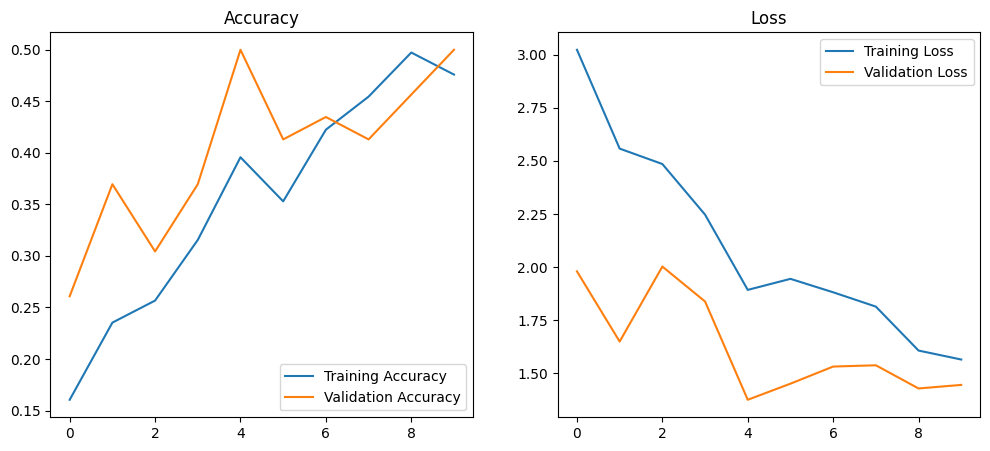

In [29]:
# Plotting Training and Accuracy
import matplotlib.pyplot as plt
import seaborn as sns

# Plot Accuracy and Loss
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.title('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.title('Loss')
plt.legend()
plt.show()

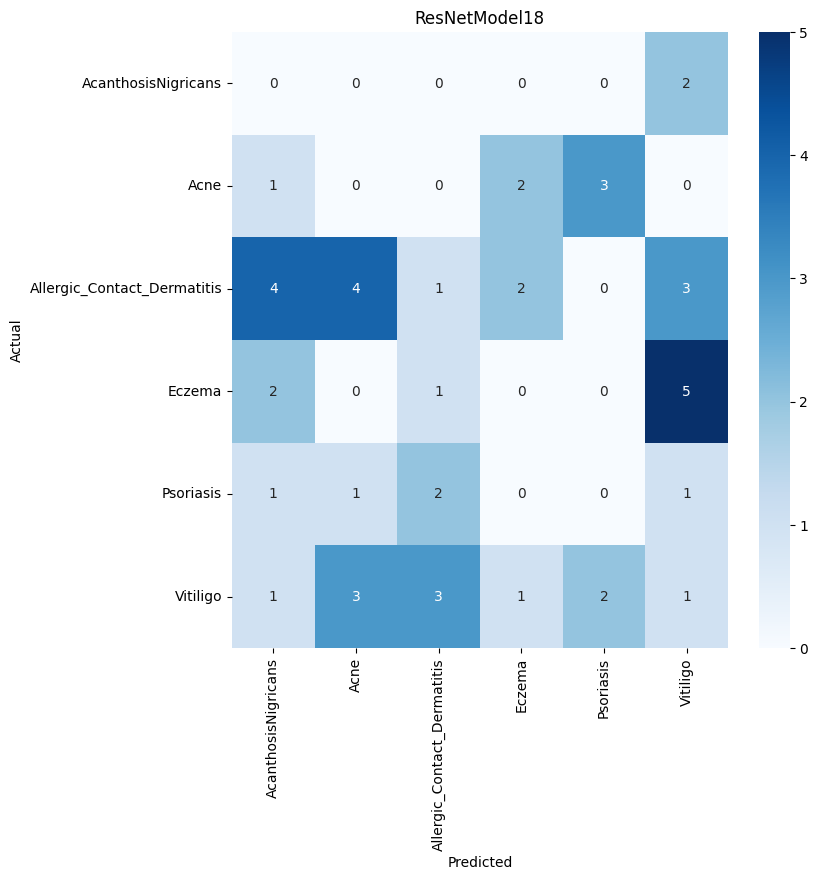

In [30]:
# plotting confusion matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_matrix(actual, predicted, labels):
    cm = tf.math.confusion_matrix(actual, predicted)

    plt.figure(figsize=(8, 8))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
                xticklabels=labels, yticklabels=labels)

    plt.title("ResNetModel18")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_matrix(true_labels, predictions, class_names)

In [28]:
# saving the model
model.save('clarity_resnet18.keras')